In [7]:
from typing import TypedDict, List, Union, Annotated, Dict, Any
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, SystemMessage
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from pydantic import BaseModel
from langchain.output_parsers import PydanticOutputParser
from system_prompts import classify_and_fill_system_content, clarify_system_content, confirm_system_content


load_dotenv()

# This schema defines what's required for each intent.
REQUIRED_SLOTS_SCHEMA = {
    "buy_airtime": ["phone_number", "network", "amount"],
    "buy_data": ["phone_number", "network", "amount"],
    "buy_electricity": ["meter_number", "amount"],
    
    # Other intents have no slot requirements
    "check_balance": [],
    "user_confirmed_YES": [],
    "user_confirmed_NO": [],
    "general_chat": []
}

class ClassifierSchema(BaseModel):
    intent: str
    slots: dict

parser = PydanticOutputParser(pydantic_object=ClassifierSchema)


class AgentState(TypedDict):
    # The conversation history. 'add_messages' is a special
    # function that appends new messages to this list.
    messages: Annotated[list, add_messages]
    
    # What does the user want? (e.g., "buy_airtime", "buy_data", "general_chat")
    intent: str
    
    # A dictionary to store collected information
    # e.g., {"phone_number": "080...", "amount": 500, "service": "mtn"}
    slots: Dict[str, Any]
    
    # What information is STILL missing to fulfill the intent?
    # e.g., ["amount", "phone_number"]
    missing_slots: List[str]
    
    # The final message from a tool (e.g., "Success!" or "Error: Failed")
    tool_response: str

@tool
def extra_data():
    """This is additional data on who Adegbite David is"""

    return "He is a back-end developer"

tools= [extra_data]
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(tools)

# System prompt to prepend only at the start
CLASSIFY_AND_FILL_SYSTEM_PROMPT = SystemMessage(content=classify_and_fill_system_content)

def classify_and_fill(state: AgentState) -> dict:
    """Call the LLM classifier and return the AIMessage as a partial state update.

    Do NOT mutate `state` in-place. Returning `{"messages": [response]}` will
    cause the `add_messages` reducer to append the AIMessage to the conversation.
    """
    messages = list(state['messages'])
    if not messages:
        print("🤖 Hi, i'm Bel AI, what would you like to do?")
        user_input = input("👤 USER: ")
        user_message = HumanMessage(content=user_input)

    else:
        user_input = input("👤 USER: ")
        user_message = HumanMessage(content=user_input)
    
    all_messages = [CLASSIFY_AND_FILL_SYSTEM_PROMPT] + list(state['messages']) + [user_message]

    response = llm.invoke(all_messages)
    print(response.content)

    intent_and_slots = dict(parser.parse(response.content))   # type: ignore

    # Return the AIMessage so the graph appends it to the messages list.
    return {"messages": [response], "intent": intent_and_slots['intent'], "slots": intent_and_slots['slots']} 

def check_for_missing_slots(state: AgentState) -> dict:
    """
    Checks the current slots against the required schema for the current intent
    and populates the 'missing_slots' list.
    """
    print("---UPDATING MISSING SLOTS---")
    
    # Get the data from the state
    intent = state['intent']
    slots = state['slots']
    
    # Get the list of required slots for this intent.
    # .get(intent, []) defaults to an empty list if the intent isn't in our schema
    required_slots = REQUIRED_SLOTS_SCHEMA.get(intent, [])
    
    missing_slots_list = []
    
    # Loop through the list of required slots
    for slot_name in required_slots:
        # Check if the slot is NOT in the state's 'slots' dict
        # or if it's there but is None or an empty string
        if not slots.get(slot_name):
            missing_slots_list.append(slot_name)
            
    print(f"Missing slots found: {missing_slots_list}")
    
    # Return a dictionary to update the state
    return {"missing_slots": missing_slots_list}

def clarify(state: AgentState) -> AgentState:
    system_prompt = clarify_system_content(str(state['missing_slots']))

    response = llm.invoke([system_prompt] + list(state['messages']))
    print(f"🤖 {response.content.strip()}")

    return state

def confirm(state: AgentState) -> AgentState:
    if state["intent"] == 'buy_electricity':
        transaction_details = str(
        {"intent": state["intent"], 
         "meter_number": state['slots']['meter_number'], 
         "amount": str(state["slots"]["amount"])})
    else:
        transaction_details = str(
            {"intent": state["intent"], 
             "phone_number": state['slots']['phone_number'], 
             "amount": str(state["slots"]["amount"]), 
             "network": state["slots"]["network"]})
    
    system_prompt = confirm_system_content(transaction_details)
    
    all_messages = [system_prompt] + list(state['messages']) 

    response = llm.invoke(all_messages)
    print(f"\n🤖 {response.content.strip()}")
    return state

def route_after_classification(state: AgentState) -> str:
    """
    Reads the 'intent' and 'missing_slots' to decide the next step.
    This is the main logic for your conditional edges.
    """
    print("---ROUTING---")
    intent = state['intent']
    missing_slots = state['missing_slots']

    # 1. Handle confirmation intents (Yes/No)
    if intent == "user_confirmed_YES":
        print("Routing to: execute_tool")
        return "execute_tool"  # Go run the API call
        
    if intent == "user_confirmed_NO":
        print("Routing to: generate_response_cancelled")
        return "generate_response_cancelled" # Go to a node that says "OK, cancelled."

    # 2. Handle transactional intents (buy_*)
    if intent in ["buy_airtime", "buy_data", "buy_electricity"]:
        if len(missing_slots) > 0:
            print("Routing to: clarify")
            return "clarify"  # Go to the 'clarify' (ask question) node
        else:
            print("Routing to: confirm")
            return "confirm"  # All info is present, go to 'confirm' node

    # 3. Handle all other intents
    print("Routing to: generate_response_chat")
    return "generate_response_chat" # Just a general chat, go to main response node

def should_use_tools(state: AgentState):
    messages = state['messages']
    last_message = messages[-1]
    
    if not last_message.tool_calls: # type: ignore
        return "end"
    else: 
        return "continue"

# initializing the graph state
graph = StateGraph(AgentState)

# nodes
graph.add_node("classify_and_fill_agent", classify_and_fill)
graph.add_node("check_for_missing_slots_node", check_for_missing_slots)
graph.add_node("clarify_agent", clarify)
graph.add_node("confirm_agent", confirm)

# tool_node = ToolNode(tools=tools)
# graph.add_node("tools", tool_node)

# edges
graph.add_edge(START, "classify_and_fill_agent")
graph.add_edge("classify_and_fill_agent", "check_for_missing_slots_node")
graph.add_conditional_edges(
    "check_for_missing_slots_node",
    route_after_classification,
    {
        "clarify": "clarify_agent",
        "confirm": "confirm_agent"
    }
)
graph.add_edge("clarify_agent", "classify_and_fill_agent")
graph.add_edge("confirm_agent", END)

# graph.add_edge("tools", "classify_and_fill_agent")

app = graph.compile()

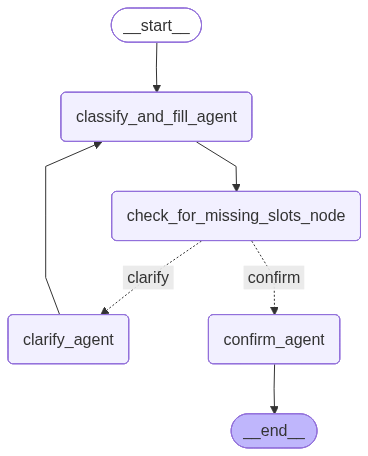

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))